<a href="https://colab.research.google.com/github/1Aadi0/GW-ANALYSIS/blob/main/GW190814.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -q -U 'numpy==1.26.4'
! pip install -q -U 'numpy==1.26.4'


Usage:   
  pip3 uninstall [options] <package> ...
  pip3 uninstall [options] -r <requirements file> ...

no such option: -U


In [2]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
# -- Use the following for Google Colab
! pip install -q -U 'scipy==1.12.0' 'lalsuite==7.25' 'PyCBC==2.4.1'

H1


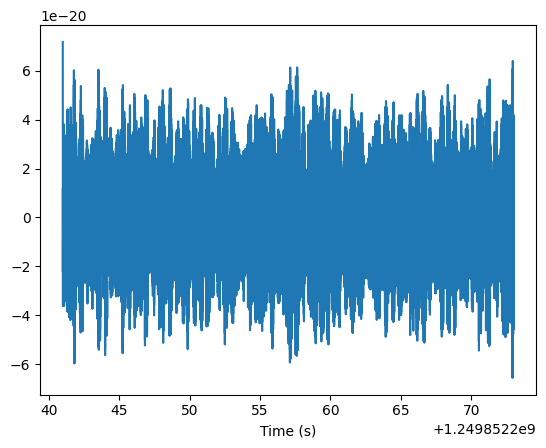

L1


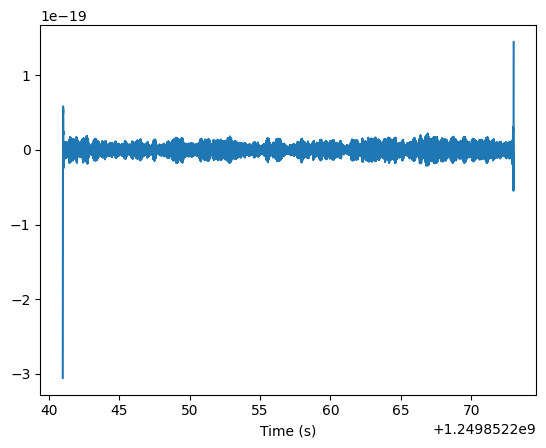

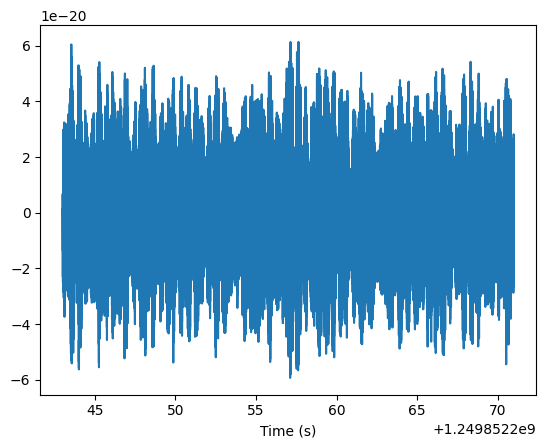

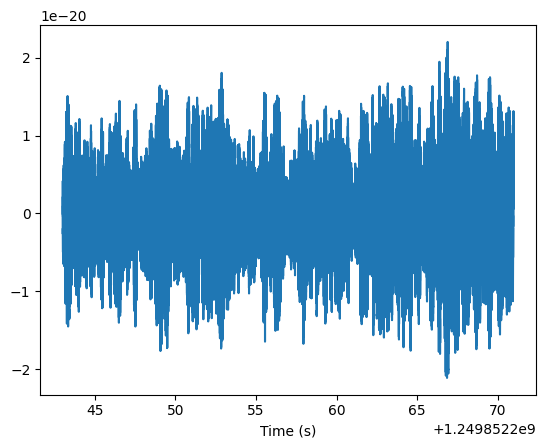

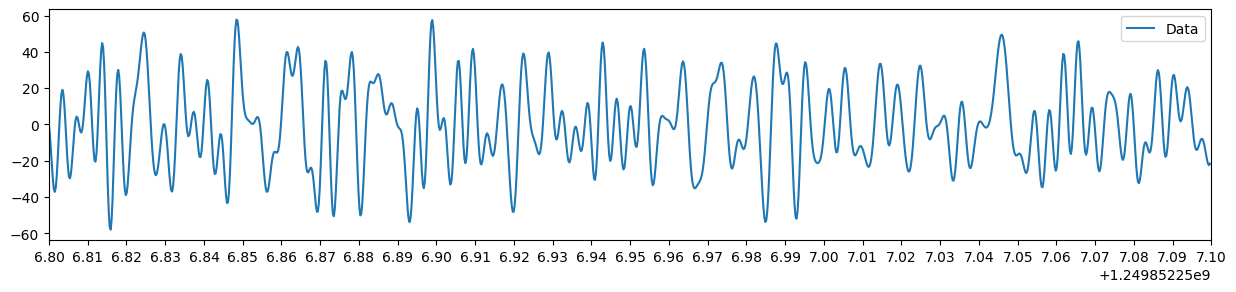

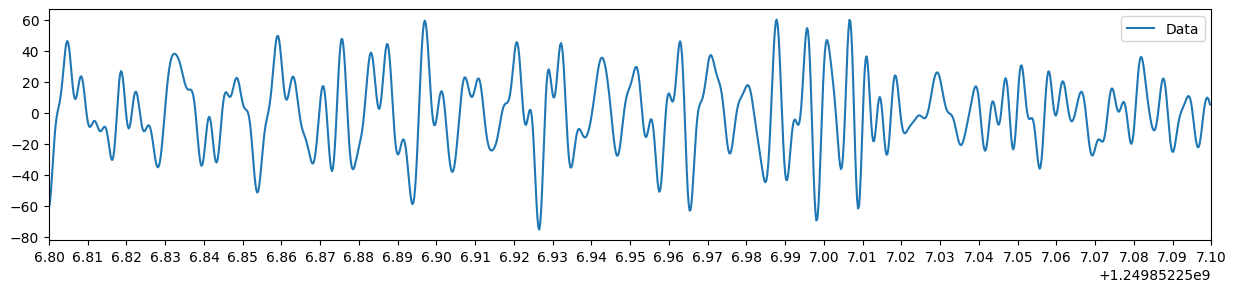

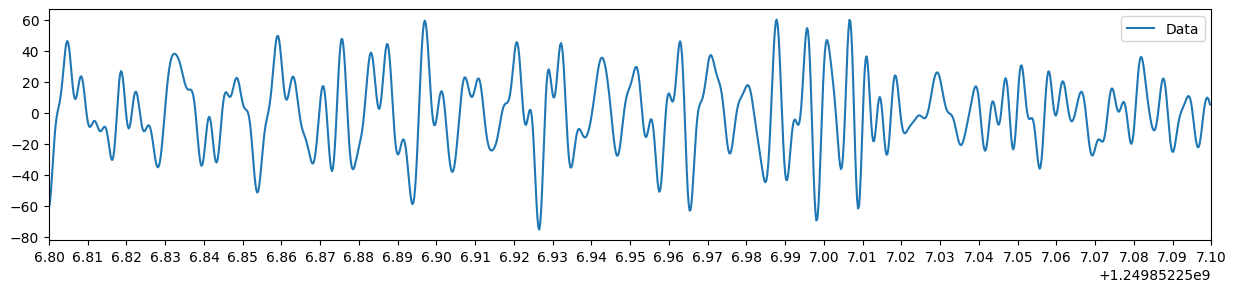

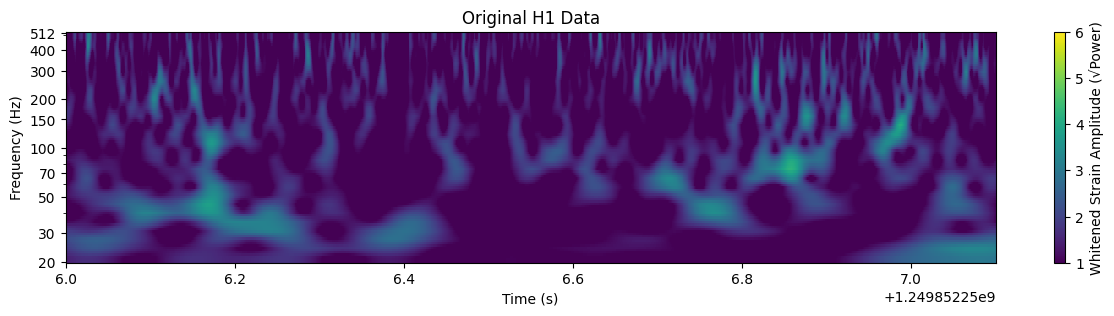

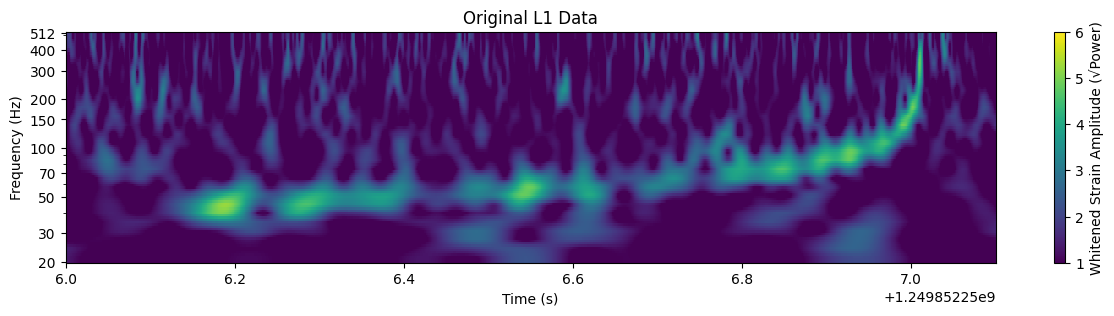

merger.time: 1249852257.0
white_data_h.start_time: 1249852256.799804688
white_data_l.start_time (before final alignment shift): 1249852256.799804688
L1_whitened_aligned.start_time (after 0.0200s shift): 1249852256.779804688


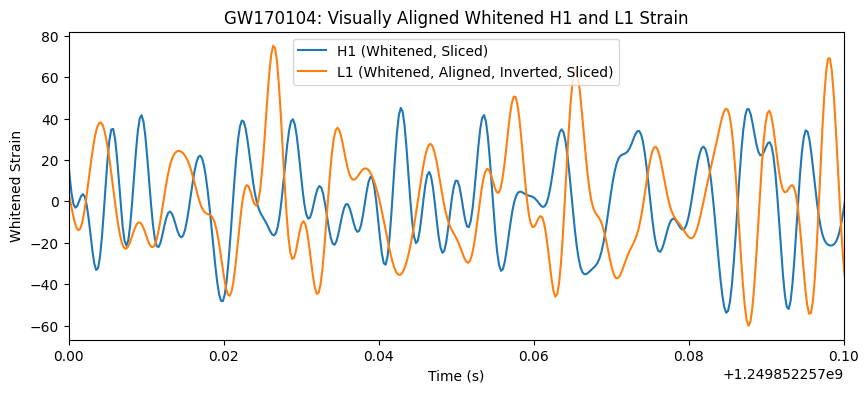

Consecutive slow oscillation zero crossings and half-cycle frequencies:
1249852256.80542  -->  1249852256.81616 | Δt=0.010742 s | f=46.55 Hz
1249852256.81616  -->  1249852256.82788 | Δt=0.011719 s | f=42.67 Hz
1249852256.82788  -->  1249852256.84033 | Δt=0.012451 s | f=40.16 Hz
1249852256.84033  -->  1249852256.85352 | Δt=0.013184 s | f=37.93 Hz
1249852256.85352  -->  1249852256.86572 | Δt=0.012207 s | f=40.96 Hz
1249852256.86572  -->  1249852256.87793 | Δt=0.012207 s | f=40.96 Hz
1249852256.87793  -->  1249852256.89014 | Δt=0.012207 s | f=40.96 Hz


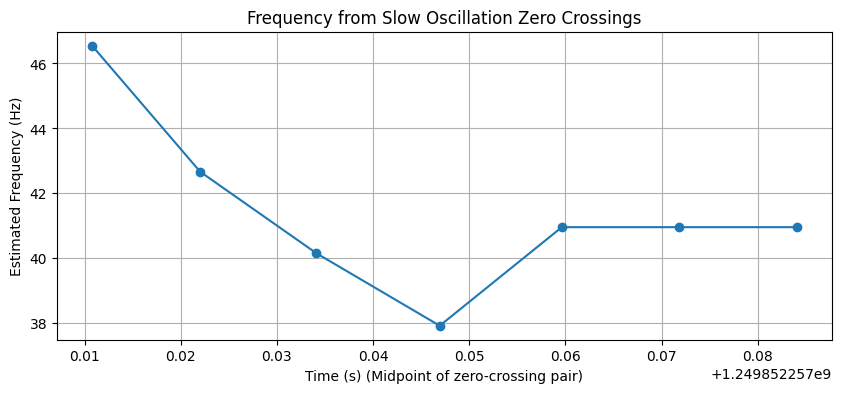

In [17]:
# The first import of matplotlib can take some time (especially on cloud platforms). This is normal.
import matplotlib.pyplot as plt
from pycbc.catalog import Merger
from pycbc.filter import resample_to_delta_t, highpass
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# As an example we use the GW150914 data
merger = Merger("GW190814")

# Get the data from the Hanford detector
strain_h = merger.strain('H1')
strain_l = merger.strain('L1')


# Remove the low frequency content and downsample the data to 2048Hz
strain_h = highpass(strain_h, 15.0)
strain_h = resample_to_delta_t(strain_h, 1.0 / 4096)  # Instead of 2048

strain_l = highpass(strain_l, 15.0)
strain_l = resample_to_delta_t(strain_l, 1.0 / 4096)  # Instead of 2048

print("H1")
plt.plot(strain_h.sample_times, strain_h)
plt.xlabel('Time (s)')
plt.show()

print("L1")
plt.plot(strain_l.sample_times, strain_l)
plt.xlabel('Time (s)')
plt.show()

# Remove 2 seconds of data from both the beginning and end
conditioned_h = strain_h.crop(2, 2)
conditioned_l = strain_l.crop(2, 2)

conditioned = (conditioned_h + conditioned_l) / 2

plt.plot(conditioned_h.sample_times, conditioned_h)
plt.xlabel('Time (s)')
plt.show()

plt.plot(conditioned_l.sample_times, conditioned_l)
plt.xlabel('Time (s)')
plt.show()

from pycbc.psd import interpolate, inverse_spectrum_truncation
# Estimate the power spectral density

# We use 4 second samples of our time series in Welch method.
psd_h = conditioned_h.psd(4)
psd_l = conditioned_l.psd(4)

# Now that we have the psd we need to interpolate it to match our data
# and then limit the filter length of 1 / PSD. After this, we can
# directly use this PSD to filter the data in a controlled manner
psd_h = interpolate(psd_h, conditioned_h.delta_f)
psd_l = interpolate(psd_l, conditioned_l.delta_f)

# 1/PSD will now act as a filter with an effective length of 4 seconds
# Since the data has been highpassed above 15 Hz, and will have low values
# below this we need to inform the function to not include frequencies
# below this frequency.
psd_h = inverse_spectrum_truncation(psd_h, int(4 * conditioned_h.sample_rate),
                                  low_frequency_cutoff=15)
psd_l = inverse_spectrum_truncation(psd_l, int(4 * conditioned_l.sample_rate),
                                  low_frequency_cutoff=15)

# from pycbc.waveform import get_td_waveform

# m1=23
# m2=2.6    # Solar masses
# hp, hc = get_td_waveform(approximant="IMRPhenomXPHM",
#                      mass1=m1,
#                      mass2=m2,
#                      delta_t=conditioned.delta_t,
#                      f_lower=20)

# Resize the vector to match our data
# hp.resize(len(conditioned))

# # Let's plot the signal before and after shifting

# plt.figure()
# plt.title('Before shifting')
# plt.plot(hp.sample_times, hp)
# plt.xlabel('Time (s)')
# plt.ylabel('Strain')

# # The template's merger is usually at hp.sample_times[-1]
# template_merger_time = hp.sample_times[-1]
# # Align so that the template's merger matches the SNR peak in data
# shift = time_h - template_merger_time
# template = hp.cyclic_time_shift(shift)

# plt.figure()
# plt.title('After shifting')
# plt.plot(template.sample_times, template)
# plt.xlabel('Time (s)')
# plt.ylabel('Strain')
# plt.show()

# from pycbc.filter import matched_filter
# import numpy

# snr_h = matched_filter(template, conditioned_h,
#                      psd=psd_l, low_frequency_cutoff=20)
# snr_l = matched_filter(template, conditioned_l,
#                      psd=psd_l, low_frequency_cutoff=20)
# # Remove time corrupted by the template filter and the psd filter
# # We remove 4 seconds at the beginning and end for the PSD filtering
# # And we remove 4 additional seconds at the beginning to account for
# # the template length (this is somewhat generous for
# # so short a template). A longer signal such as from a BNS, would
# # require much more padding at the beginning of the vector.
# snr_h = snr_h.crop(4 + 4, 4)
# snr_l = snr_l.crop(4 + 4, 4)

# snr = (snr_h + snr_l) / 2

# # Why are we taking an abs() here?
# # The `matched_filter` function actually returns a 'complex' SNR.
# # What that means is that the real portion corresponds to the SNR
# # associated with directly filtering the template with the data.
# # The imaginary portion corresponds to filtering with a template that
# # is 90 degrees out of phase. Since the phase of a signal may be
# # anything, we choose to maximize over the phase of the signal.
# plt.figure(figsize=[10, 4])
# plt.plot(snr_h.sample_times, abs(snr_h))
# plt.ylabel('Signal-to-noise')
# plt.xlabel('Time (s)')
# plt.show()


# plt.figure(figsize=[10, 4])
# plt.plot(snr_l.sample_times, abs(snr_l))
# plt.ylabel('Signal-to-noise')
# plt.xlabel('Time (s)')
# plt.show()

# peak_h = abs(snr_h).numpy().argmax()
# snrp_h = snr_h[peak_h]
# time_h = snr_h.sample_times[peak_h]

# peak_l = abs(snr_l).numpy().argmax()
# snrp_l = snr_l[peak_l]
# time_l = snr_l.sample_times[peak_l]

# print("We found a signal at {}s with SNR {}".format(time_h, abs(snrp_h)))

# print("We found a signal at {}s with SNR {}".format(time_l, abs(snrp_l)))

# from pycbc.filter import sigma
# # The time, amplitude, and phase of the SNR peak tell us how to align
# # our proposed signal with the data.

# # Shift the template to the peak time
# dt_h = time_h - conditioned_h.start_time
# # aligned = template.cyclic_time_shift(dt)

# dt_l = time_l - conditioned_l.start_time
# aligned_h = template.cyclic_time_shift(dt_h)
# aligned_l = template.cyclic_time_shift(dt_l)

# # scale the template so that it would have SNR 1 in this data
# aligned_h /= sigma(aligned_h, psd=psd_h, low_frequency_cutoff=20.0)
# aligned_l /= sigma(aligned_l, psd=psd_l, low_frequency_cutoff=20.0)

# # Scale the template amplitude and phase to the peak value
# aligned_h = (aligned_h.to_frequencyseries() * snrp_h).to_timeseries()
# aligned_h.start_time = conditioned_h.start_time

# aligned_l = (aligned_l.to_frequencyseries() * snrp_l).to_timeseries()
# aligned_l.start_time = conditioned_l.start_time

# We do it this way so that we can whiten both the template and the data
white_data_h = (conditioned_h.to_frequencyseries() / psd_h**0.5).to_timeseries()
# white_template_h = (aligned_h.to_frequencyseries() / psd_h**0.5).to_timeseries()

white_data_l = (conditioned_l.to_frequencyseries() / psd_l**0.5).to_timeseries()
# white_template_l= (aligned_l.to_frequencyseries() / psd_l**0.5).to_timeseries()

white_data_h = white_data_h.highpass_fir(30., 512).lowpass_fir(300, 512)
# white_template_h = white_template_h.highpass_fir(30, 512).lowpass_fir(300, 512)

white_data_l = white_data_l.highpass_fir(30., 512).lowpass_fir(300, 512)
# white_template_l = white_template_l.highpass_fir(30, 512).lowpass_fir(300, 512)

white_data = (white_data_h + white_data_l) / 2

# Select the time around the merger
white_data_h = white_data_h.time_slice(merger.time-.2, merger.time+.1)
# white_template_h = white_template_h.time_slice(merger.time-.2, merger.time+.1)

white_data_l = white_data_l.time_slice(merger.time-.2, merger.time+.1)
# white_template_l = white_template_l.time_slice(merger.time-.2, merger.time+.1)

plt.figure(figsize=[15, 3])
plt.plot(white_data_h.sample_times, white_data_h, label="Data")
# plt.plot(white_template_h.sample_times, white_template_h, label="Template")
plt.legend()
plt.xlim(merger.time - 0.2, merger.time + 0.1)
xticks = np.arange(merger.time - 0.2, merger.time + 0.1 + 0.01, 0.01)
plt.xticks(xticks)
plt.show()

plt.figure(figsize=[15, 3])
plt.plot(white_data_l.sample_times, white_data_l, label="Data")
# plt.plot(white_template_l.sample_times, white_template_l, label="Template")
plt.legend()
plt.xlim(merger.time - 0.2, merger.time + 0.1)
xticks = np.arange(merger.time - 0.2, merger.time + 0.1 + 0.01, 0.01)
plt.xticks(xticks)
plt.show()

plt.figure(figsize=[15, 3])
plt.plot(white_data_l.sample_times, white_data_l, label="Data")
# plt.plot(white_template_l.sample_times, white_template_l, label="Template")
plt.legend()
plt.xlim(merger.time - 0.2, merger.time + 0.1)
xticks = np.arange(merger.time - 0.2, merger.time + 0.1 + 0.01, 0.01)
plt.xticks(xticks)
plt.show()


# Subtract the template from the data

# subtracted_h = conditioned_h - aligned_h
# subtracted_l = conditioned_l - aligned_l


# Plot the original data and the subtracted signal data

for data, title in [(conditioned_h, 'Original H1 Data'),(conditioned_l, 'Original L1 Data')]:

    t, f, p = data.whiten(4, 4).qtransform(.001, logfsteps=100, qrange=(8, 8), frange=(20, 512))
    plt.figure(figsize=[15, 3])
    plt.title(title)
    mesh = plt.pcolormesh(t, f, p**0.5, vmin=1, vmax=6, shading='auto')
    plt.colorbar(mesh, label='Whitened Strain Amplitude (√Power)')
    plt.yscale('log')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    tick_values = [20, 30, 50, 70, 100, 150, 200, 300, 400, 512]
    tick_labels = [str(val) for val in tick_values] # Create string versions of your tick values
    plt.yticks(tick_values, tick_labels)
    window_before = 1 # e.g., 0.5 seconds before the peak
    window_after = 0.1  # e.g., 0.2 seconds after the peak
    plt.xlim(merger.time - window_before, merger.time + window_after)
    plt.show()


# At the end of your script, for the final comparison plot:

# Correct delay for GW170104: L1 is ~0.003s after H1.
# To align L1 to H1, shift L1 earlier.
# At the end of your script, for the final comparison plot:

# Empirically determined shift to align L1 with H1 for plotting.
# The geocentrically corrected white_data_l appears ~2ms earlier than white_data_h.
# So, we shift white_data_l by +0.002s (later) for visual alignment.
aligning_shift_for_L1 = +0.020

L1_whitened_aligned = white_data_l.cyclic_time_shift(aligning_shift_for_L1)
L1_whitened_aligned_inverted = -L1_whitened_aligned # Invert for visual comparison

# --- Optional print statements for verification ---
print(f"merger.time: {merger.time}")
print(f"white_data_h.start_time: {white_data_h.start_time}")
print(f"white_data_l.start_time (before final alignment shift): {white_data_l.start_time}")
print(f"L1_whitened_aligned.start_time (after {aligning_shift_for_L1:.4f}s shift): {L1_whitened_aligned.start_time}")
# --- End of print statements ---

plt.figure(figsize=(10, 4))
plt.plot(white_data_h.sample_times, white_data_h, label='H1 (Whitened, Sliced)')
plt.plot(L1_whitened_aligned_inverted.sample_times, L1_whitened_aligned_inverted, label='L1 (Whitened, Aligned, Inverted, Sliced)')

plt.xlim(merger.time - 0.1, merger.time + 0.)
plt.xlabel("Time (s)")
plt.ylabel("Whitened Strain")
plt.title("GW170104: Visually Aligned Whitened H1 and L1 Strain")
plt.legend()
plt.show()



# data: your blue waveform (e.g., white_data_h or similar)
# time: corresponding sample_times array

# 1. Get analytic signal and envelope
# Assuming plt is still needed if you want to plot

# Assuming 'white_data_l' and 'merger' are already defined from your script
# For example:
# data = white_data_l
# time = white_data_l.sample_times

# If white_data_l is not in scope, you'd need to re-run the parts of your script
# that generate it. For this snippet, I'll assume it exists.

# Ensure 'data' and 'time' are correctly assigned from your TimeSeries object
data_array = white_data_l.numpy()  # Get data as a NumPy array
time_array = white_data_l.sample_times.numpy() # Get time as a NumPy array
delta_t_val = white_data_l.delta_t # Get delta_t

fs = int(1.0 / delta_t_val)  # Sampling frequency
cutoff = 40  # Hz, this was the cutoff for the "slow" oscillations
order = 4
b, a = butter(order, cutoff / (0.5 * fs), btype='low', analog=False)
slow_data = filtfilt(b, a, data_array)

# Set window around the merger (you can adjust this as needed)
# This was one of the windows we discussed:
start_time_window = merger.time - 0.2
end_time_window = merger.time - 0.1

# Create a mask for the time window
mask = (time_array >= start_time_window) & (time_array <= end_time_window)
time_window = time_array[mask]
slow_window = slow_data[mask]

# Find zero crossings of the slow signal in your window
# np.diff(np.sign(slow_window)) will be non-zero where sign changes
# The [0] at the end gets the indices from the tuple returned by np.where
zero_crossing_indices = np.where(np.diff(np.sign(slow_window)))[0]

# Get the actual times of these zero crossings
zero_crossing_times = time_window[zero_crossing_indices]

print("Consecutive slow oscillation zero crossings and half-cycle frequencies:")
# Loop through pairs of consecutive zero crossings
for i in range(len(zero_crossing_times) - 1):
    t1 = zero_crossing_times[i]
    t2 = zero_crossing_times[i+1]
    delta = t2 - t1  # Time difference between crossings

    # Calculate frequency for this half-cycle
    # The period of one full oscillation is roughly 2*delta
    frequency = 1.0 / (2 * delta) if delta != 0 else float('inf')

    print(f"{t1:.5f}  -->  {t2:.5f} | Δt={delta:.6f} s | f={frequency:.2f} Hz")

# Optional: Plotting the frequencies (if you want to visualize the trend)
if len(zero_crossing_times) > 1:
    midpoints = (zero_crossing_times[:-1] + zero_crossing_times[1:]) / 2
    frequencies_calculated = [1.0 / (2 * (zero_crossing_times[j+1] - zero_crossing_times[j]))
                              for j in range(len(zero_crossing_times) - 1)]

    plt.figure(figsize=(10,4))
    plt.plot(midpoints, frequencies_calculated, marker='o', linestyle='-')
    plt.xlabel("Time (s) (Midpoint of zero-crossing pair)")
    plt.ylabel("Estimated Frequency (Hz)")
    plt.title("Frequency from Slow Oscillation Zero Crossings")
    plt.grid(True)
    plt.show()
else:
    print("Not enough zero crossings found in the window to calculate frequencies.")
